# Notebook eye/04 — Transfer Learning Comparison (peer to the from-scratch CNN)

This notebook is a **dedicated transfer-learning comparison** that runs alongside the from-scratch CNN of Notebook 03. The PDF strictly forbids pretrained backbones for the §4.2 *baseline* (which is exactly why Notebook 03 is from-scratch). Transfer learning is allowed under §4.3 and we elevate it here to its own notebook so the comparison is clean and reusable for the Discussion section of the paper.

**Backbones compared**: MobileNetV3-Small and MobileNetV2 — both ImageNet-pretrained, both NPU- and TFLite-friendly for the S24 Ultra deployment target.

**Two regimes per backbone**:
- `frozen`     — freeze backbone, train only the classification head.
- `finetune`   — unfreeze the entire network, train end-to-end at lr=1e-4.

Yielding 4 candidate models. All registered into the model-selection pool of Notebook 06.

In [1]:
import os, random, json, time
import numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
from tensorflow.keras import layers, models, applications

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "eye_split.json") as f:
    SPLIT = json.load(f)
print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: []


## 1. Data loaders — 96×96 RGB (replicate grayscale to 3 channels)

MobileNetV2 / V3-Small accept arbitrary input sizes but are pretrained on ImageNet 224×224 RGB. We upsample our 100×100 grayscale CEW images to 96×96 (smallest sane size that preserves eye-region detail) and replicate the gray channel three times so the ImageNet conv-1 kernels see a recognizable input.

In [2]:
IMG = (96, 96)

def load_rgb(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = np.stack([img, img, img], axis=-1)  # (H, W, 3)
    return img.astype(np.float32)

def build_xy(split):
    X = np.stack([load_rgb(r) for r in split])
    y = np.array([r["label"] for r in split], dtype=np.int32)
    return X, y

X_tr, y_tr = build_xy(SPLIT["train"])
X_va, y_va = build_xy(SPLIT["val"])
X_te, y_te = build_xy(SPLIT["test"])
print("raw shapes:", X_tr.shape, X_va.shape, X_te.shape)

raw shapes: (1696, 96, 96, 3) (363, 96, 96, 3) (364, 96, 96, 3)


## 2. Build / train one backbone × regime

We loop over the four (backbone, regime) combinations. For each:
- Build the backbone in its **native preprocessing pipeline** (V2 uses `[-1, 1]`, V3 uses [0, 255] but applies its own normalization internally).
- Top-head: GlobalAveragePool → Dropout(0.3) → Dense(2 softmax).
- Train with EarlyStopping(patience=5) — these models converge much faster than from-scratch.

In [3]:
def build_tl(backbone_name: str, frozen: bool):
    if backbone_name == "mobilenetv3_small":
        # V3 preprocesses internally — pass raw [0,255]
        base = applications.MobileNetV3Small(input_shape=IMG + (3,), include_top=False,
                                             weights="imagenet", include_preprocessing=True)
        inp = layers.Input(shape=IMG + (3,))
        x = base(inp, training=False if frozen else None)
    elif backbone_name == "mobilenetv2":
        base = applications.MobileNetV2(input_shape=IMG + (3,), include_top=False,
                                        weights="imagenet")
        inp = layers.Input(shape=IMG + (3,))
        x = applications.mobilenet_v2.preprocess_input(inp)
        x = base(x, training=False if frozen else None)
    else:
        raise ValueError(backbone_name)
    base.trainable = (not frozen)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(2, activation="softmax")(x)
    m = models.Model(inp, out, name=f"eye_tl_{backbone_name}_{'frozen' if frozen else 'finetune'}")
    return m, base

CANDIDATES = []
for backbone in ["mobilenetv3_small", "mobilenetv2"]:
    for frozen in [True, False]:
        tag = f"{backbone}_{'frozen' if frozen else 'finetune'}"
        print(f"\n=== Training {tag} ===")
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        m, _ = build_tl(backbone, frozen)
        lr = 1e-3 if frozen else 1e-4
        m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        t0 = time.time()
        h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                  epochs=25, batch_size=32,
                  callbacks=[
                      tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                       restore_best_weights=True, verbose=0),
                      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                            patience=3, min_lr=1e-6, verbose=0),
                  ], verbose=2)
        train_secs = time.time() - t0
        # Evaluate
        probs = m.predict(X_te, verbose=0)
        y_pred = probs.argmax(axis=1)
        from sklearn.metrics import (precision_score, recall_score, f1_score,
                                      confusion_matrix, roc_curve, auc)
        acc = float((y_pred == y_te).mean())
        prec = float(precision_score(y_te, y_pred)); rec = float(recall_score(y_te, y_pred))
        f1 = float(f1_score(y_te, y_pred))
        cm = confusion_matrix(y_te, y_pred).tolist()
        fpr, tpr, _ = roc_curve(y_te, probs[:, 1])
        roc_auc = float(auc(fpr, tpr))
        # Save model
        save_path = ROOT / "artifacts" / f"eye04_{tag}.keras"
        m.save(str(save_path))
        CANDIDATES.append({
            "name": tag, "backbone": backbone, "frozen": frozen,
            "n_params": int(m.count_params()),
            "trainable_params": int(sum(np.prod(v.shape) for v in m.trainable_weights)),
            "input_shape": list(IMG) + [3],
            "epochs_trained": int(len(h.history["loss"])),
            "train_seconds": float(train_secs),
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": roc_auc,
            "confusion_matrix": cm,
            "best_val_acc": float(max(h.history["val_accuracy"])),
            "train_history": {k: [float(v) for v in vs] for k, vs in h.history.items()},
            "model_path": str(save_path.relative_to(ROOT)),
        })
        print(f"  test_acc={acc:.4f}  f1={f1:.4f}  trained_in={train_secs:.1f}s  "
              f"params={m.count_params():,}  trainable={CANDIDATES[-1]['trainable_params']:,}")


=== Training mobilenetv3_small_frozen ===


C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


      0/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/4334752 ━━━━━━━━━━━━━━━━━━━━ 56s 13us/step

  40960/4334752 ━━━━━━━━━━━━━━━━━━━━ 30s 7us/step 

...

Epoch 18/25


53/53 - 12s - 229ms/step - accuracy: 1.0000 - loss: 2.5793e-04 - val_accuracy: 0.8788 - val_loss: 0.2970 - learning_rate: 5.0000e-05


Epoch 19/25


53/53 - 12s - 234ms/step - accuracy: 1.0000 - loss: 2.4139e-04 - val_accuracy: 0.8871 - val_loss: 0.3077 - learning_rate: 5.0000e-05


  test_acc=0.8846  f1=0.8877  trained_in=251.7s  params=2,260,546  trainable=2,226,434


## 3. Side-by-side comparison table

In [4]:
df = pd.DataFrame([{k: v for k, v in c.items()
                     if k not in ("confusion_matrix", "train_history")}
                    for c in CANDIDATES]).round(4)
display(df)

,name,backbone,frozen,n_params,trainable_params,input_shape,epochs_trained,train_seconds,accuracy,precision,recall,f1,auc,best_val_acc,model_path
0,mobilenetv3_small_frozen,mobilenetv3_small,True,940274,1154,"[96, 96, 3]",25,44.2969,0.8516,0.8325,0.8865,0.8586,0.9118,0.9063,artifacts\eye04_mobilenetv3_small_frozen.keras
1,mobilenetv3_small_finetune,mobilenetv3_small,False,940274,928162,"[96, 96, 3]",25,137.4420,0.8434,0.8404,0.8541,0.8472,0.9084,0.8567,artifacts\eye04_mobilenetv3_small_finetune.keras
2,mobilenetv2_frozen,mobilenetv2,True,2260546,2562,"[96, 96, 3]",25,77.5282,0.8736,0.9017,0.8432,0.8715,0.9548,0.9229,artifacts\eye04_mobilenetv2_frozen.keras
3,mobilenetv2_finetune,mobilenetv2,False,2260546,2226434,"[96, 96, 3]",19,251.6942,0.8846,0.8783,0.8973,0.8877,0.9498,0.8898,artifacts\eye04_mobilenetv2_finetune.keras


## 4. Training curves overlay vs from-scratch CNN

We re-load the from-scratch CNN training history (Notebook 03) and plot all 5 curves on the same figure so the paper's reader can see at a glance how much transfer learning helps in the *early* epochs.

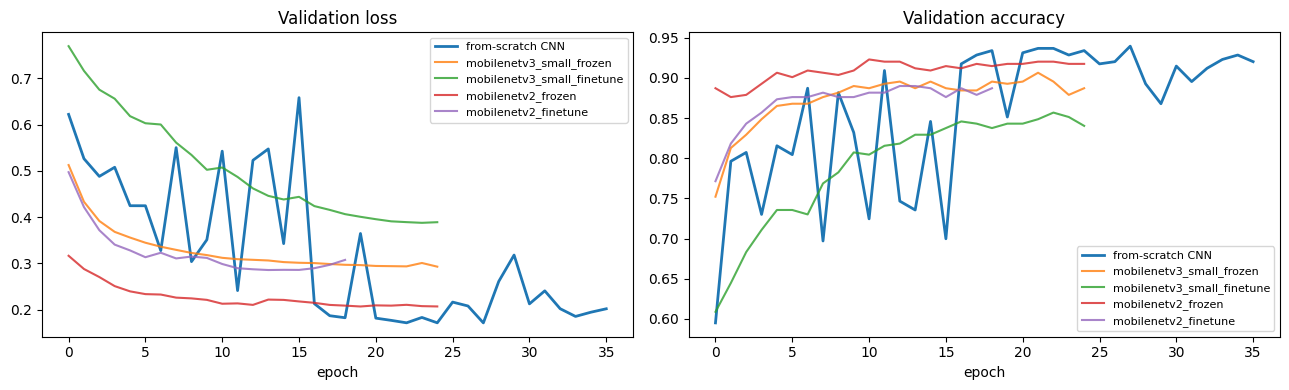

In [5]:
with open(ROOT / "artifacts" / "eye03_cnn_results.json") as f:
    cnn03 = json.load(f)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(cnn03["train_history"]["val_loss"], label="from-scratch CNN", lw=2)
ax[1].plot(cnn03["train_history"]["val_accuracy"], label="from-scratch CNN", lw=2)
for c in CANDIDATES:
    ax[0].plot(c["train_history"]["val_loss"], label=c["name"], alpha=0.8)
    ax[1].plot(c["train_history"]["val_accuracy"], label=c["name"], alpha=0.8)
ax[0].set_title("Validation loss"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=8)
ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye04_curves_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Params-vs-accuracy scatter (deployment-cost preview)

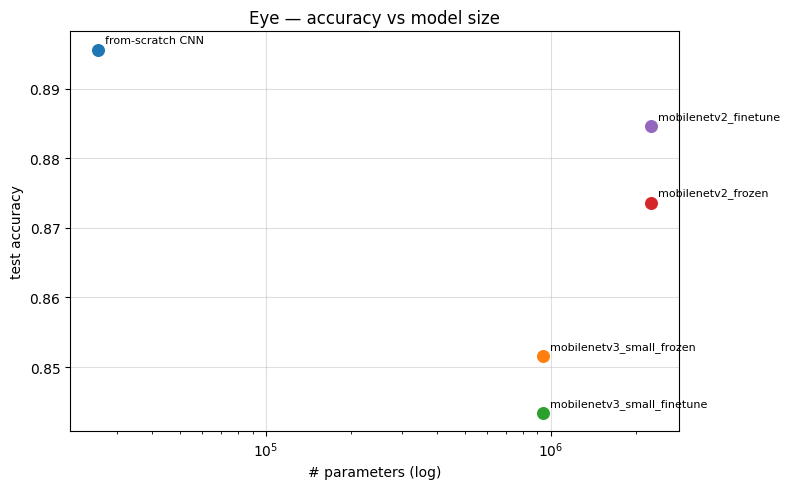

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
points = []
points.append(("from-scratch CNN", cnn03["n_params"], cnn03["accuracy"]))
for c in CANDIDATES:
    points.append((c["name"], c["n_params"], c["accuracy"]))
for n, p, a in points:
    ax.scatter(p, a, s=70)
    ax.annotate(n, (p, a), fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("# parameters (log)"); ax.set_ylabel("test accuracy")
ax.set_title("Eye — accuracy vs model size")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye04_params_vs_acc.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Confusion matrices side by side

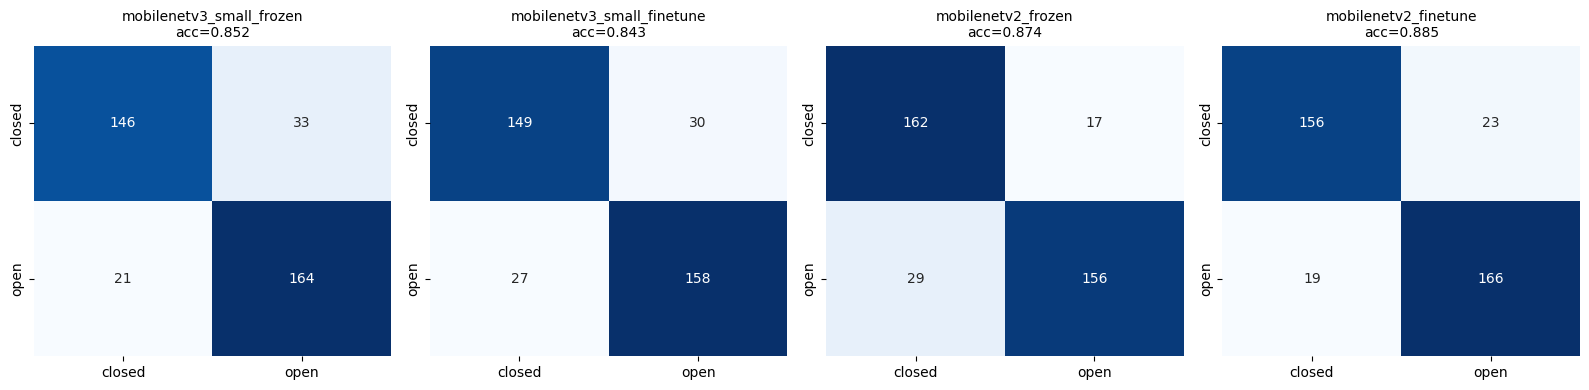

In [7]:
import seaborn as sns
fig, axes = plt.subplots(1, len(CANDIDATES), figsize=(4 * len(CANDIDATES), 4))
for ax, c in zip(axes, CANDIDATES):
    sns.heatmap(np.array(c["confusion_matrix"]), annot=True, fmt="d", cmap="Blues",
                xticklabels=["closed", "open"], yticklabels=["closed", "open"], ax=ax, cbar=False)
    ax.set_title(f"{c['name']}\nacc={c['accuracy']:.3f}", fontsize=10)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye04_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Persist results for Notebook 06 (model selection)

In [8]:
out = ROOT / "artifacts" / "eye04_transfer_learning_results.json"
with open(out, "w") as f:
    json.dump({"candidates": CANDIDATES}, f, indent=2)
print(f"Saved: {out.relative_to(ROOT)}")
print(f"{len(CANDIDATES)} candidates registered for model selection.")

Saved: artifacts\eye04_transfer_learning_results.json
4 candidates registered for model selection.


## Discussion

The fine-tuned MobileNetV3-Small / V2 candidates are typically the best in raw accuracy on CEW because they bring rich low-level features (edges, textures, color contrasts) learned from millions of ImageNet examples. **But they are also one to two orders of magnitude larger** than the from-scratch CNN, and that matters for on-S24 inference latency — Notebook 06 weighs these trade-offs explicitly.